# Example likelihood calculations for photometric probes (WL, GCph, 2x2pt, and 3x2pt)

Currently implemented only for harmonic-space observables

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihood computations
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_WL, EuclidLikelihood_GCph, EuclidLikelihood_3x2pt

/Users/zahra/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


/Users/zahra/anaconda3/lib/python3.10/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Download Synthetic Data

We are currently developing homogeneous synthetic data vectors, mixing matrices, and covariance matrices that are compatible with [euclidlib](https://github.com/euclidlib/euclidlib) and adhere to the data format specifications used by the Euclid Science Ground Segment (LE3).

> ⚠️ This effort is still ongoing. Interfaces and file availability may change as development progresses.


In [2]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits',
        'cov_WL.npz': 'https://zenodo.org/records/17191365/files/cov_WL.npz',
        'cov_GCph.npz': 'https://zenodo.org/records/17191365/files/cov_GC.npz',
        'cov_3x2pt.npz': 'https://zenodo.org/records/17191365/files/cov_3x2pt.npz'
    }
    
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

nz_example.fits downloaded successfully
mixmats_example.fits downloaded successfully
cls_example.fits downloaded successfully
cov_WL.npz downloaded successfully
cov_GCph.npz downloaded successfully
cov_3x2pt.npz downloaded successfully


## Read the Data and Normalise $n(z)$

To begin working with the photometric observables, the first step involves reading the data and normalising the redshift distribution, $n(z)$.

> **Note**: You will need to have installed `euclidlib` version **v2025.2**. Version **v2025.1** is also compatible.

Ensure you have the necessary input files (e.g., redshift distributions, masks, and bias functions) and follow the loading routines provided in the `euclidlib.photo` module.


In [3]:
# Get n(z)
z_nz, nz_heracles = el.photo.redshift_distributions('nz_example.fits')

# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_heracles, z_nz, myz)
my_dndz_she_norm = normalize_and_resample(nz_heracles, z_nz, myz)


In [4]:
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
cls_data = el.photo.angular_power_spectra('cls_example.fits')
mixmats = el.photo.mixing_matrices('mixmats_example.fits')

# This matrix copies the format of seaborne, that produces a full 3x2pt matrix
covmat_WL = np.load("cov_WL.npz")['arr_0']
covmat_GC = np.load("cov_GCph.npz")['arr_0']
#covmat_2x2pt = np.load("cov_2x2pt.npz")['arr_0']
covmat_3x2pt = np.load("cov_3x2pt.npz")['arr_0']

## Prepare Data Dictionary

We envision that the preparation of data will become significantly simpler once a unified format for reading inputs is adopted. This standardised structure will allow for easier integration of synthetic data vectors, mixing matrices, and covariance matrices into the likelihood evaluation pipeline. 


In [5]:
def build_data(ell_key, cov, include_pos=False, include_she=False):
    data = {
        'cells': cls_data,
        'ells': cls_data[ell_key].ell,
        'z_arr': myz,
        'cov': cov,
        'mixmat': mixmats,
    }
    if include_pos:
        data['dndz_pos'] = my_dndz_pos_norm
    if include_she:
        data['dndz_she'] = my_dndz_she_norm
    return data

def build_settings():
    scale_cuts = {key: [5, 3000] for key in cls_data}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

# Build each dataset with correct dndz components
data_WL     = build_data(('SHE', 'SHE', 1, 1), covmat_WL,         include_she=True)
data_GC     = build_data(('POS', 'POS', 1, 1), covmat_GC,         include_pos=True)
data_3x2pt  = build_data(('POS', 'POS', 1, 1), covmat_3x2pt,      include_pos=True, include_she=True)

# Settings (same for all, built from cells_data structure)
settings_WL     = build_settings()
settings_GC     = build_settings()
settings_3x2pt  = build_settings()

## Likelihood Initialisation

This block handles the initialisation of the Euclid photometric likelihoods in harmonic space. For each observable probe, we construct the corresponding likelihood class instance using the appropriate data and settings dictionaries:

- **WL**: Weak Lensing
- **GC**: Photometric Galaxy Clustering
- **3x2pt**: Full combination of WL, GC, and GGL

Each likelihood is instantiated with the required cosmological components:
- `CAMBBackground` for background evolution
- `HMemuLinearPerturbations` for linear theory
- `HMemuNonLinearPerturbations` for non-linear corrections

We also time the initialisation process to estimate setup costs for each likelihood. This is particularly useful for understanding performance when running larger parameter scans or MCMC chains.

In [6]:
import time

likelihood_classes = {
    'WL': EuclidLikelihood_WL,
    'GC': EuclidLikelihood_GCph,
    '3x2pt': EuclidLikelihood_3x2pt,
}

data_dicts = {
    'WL': (data_WL, settings_WL),
    'GC': (data_GC, settings_GC),
    '3x2pt': (data_3x2pt, settings_3x2pt),
}

like_tests = {}
loglike_results = {}

print("🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:")

for label in ['WL', 'GC', '3x2pt']:
    print(f"\n📊 {label} loglike:")
    data, settings = data_dicts[label]
    cls = likelihood_classes[label]

    start = time.time()
    like_tests[label] = cls(
        data=data,
        settings=settings,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
    )
    end = time.time()

    print(f"⏱️ Time elapsed ({label}): {end - start:.3f} seconds")


🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:

📊 WL loglike:
⏱️ Time elapsed (WL): 0.008 seconds

📊 GC loglike:
⏱️ Time elapsed (GC): 0.007 seconds

📊 3x2pt loglike:
⏱️ Time elapsed (3x2pt): 0.007 seconds


## Likelihood Evaluation

In this section, we perform a single evaluation of the log-likelihood for each photometric probe at the fiducial cosmological parameters. 

We use a dictionary of initialized likelihood objects (`like_tests`) and evaluate their `loglike()` method using a shared set of default parameters. The execution time for each evaluation is recorded to give a sense of computational cost.

This diagnostic helps verify the setup and responsiveness of the likelihood components for each probe before launching more detailed analyses.


In [7]:
# These are the default parameters used to generate the synthetic data, therefore, the log-likelihood should be close to zero.
default_pars = {'H0':70,'Omega_cdm0':0.25,'Omega_b0':0.05,'ns':0.96,'As':2.1e-9,
                'w0':-1,'wa':0, 'Omega_k0':0,'mnu':0.06,'gamma_MG':0.545, 'N_mnu': 1, 
                'log10TAGN': 7.8,
                'AIA':0., 'EtaIA': 0, 'CIA': 0.0,
                'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414,
                'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
                'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                'dz_shear_5': 0.0, 'dz_shear_6': 0.0}

In [8]:
# Dictionary of pretty names for output
labels_pretty = {
    'WL': "Weak Lensing (WL)",
    'GC': "Photometric Angular Galaxy Clustering (GC)",
    '3x2pt': "3x2pt"
}

print("⏱️ Timing log-likelihood evaluations and displaying results:")

loglike_results = {}

for label in ['WL', 'GC', '3x2pt']:
    print(f"\n📊 {labels_pretty[label]} loglike:")
    start = time.time()
    result = like_tests[label].loglike(default_pars)
    elapsed = time.time() - start
    loglike_results[label] = result
    print(f"✅ Returned value ({label}): {result}")
    print(f"⏱️ Time elapsed ({label}): {elapsed:.3f} seconds")


⏱️ Timing log-likelihood evaluations and displaying results:

📊 Weak Lensing (WL) loglike:
✅ Returned value (WL): -27.651629352977317
⏱️ Time elapsed (WL): 2.754 seconds

📊 Photometric Angular Galaxy Clustering (GC) loglike:
✅ Returned value (GC): -570.5364830400096
⏱️ Time elapsed (GC): 0.919 seconds

📊 3x2pt loglike:
✅ Returned value (3x2pt): -84529.1324581831
⏱️ Time elapsed (3x2pt): 0.821 seconds


You can always retrieve the theoretical prediction computed during the $\chi^2$ calculation and the derived parameters such as (in dictionary shape):

In [9]:
print(like_tests['WL'].theory_prediction)
print(like_tests['WL'].derived)

{('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 2): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 2): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', '

## Exploring the Parameter Space

This section illustrates how we explore the dependence of photometric observables on the cold dark matter density parameter, $\Omega_{\rm cdm} h^2$. We scan a range of values and evaluate the likelihood for each photometric probe: Weak Lensing (WL), Galaxy Clustering (GC), 2x2pt (GC + GGL), and 3x2pt.

The likelihoods are computed using the corresponding Euclid likelihood classes, and we normalize each resulting curve to its maximum value for easier visual comparison. A vertical dashed line indicates a fiducial $\Omega_{\rm cdm} h^2$ value (e.g., the best fit).

We use `tqdm` to visually track the progress of likelihood evaluations for each probe.


🔄 Scanning over $\Omega_{cdm} h^2$ for GC


GC: 100%|███████████████████████████████████████| 50/50 [00:06<00:00,  7.71it/s]


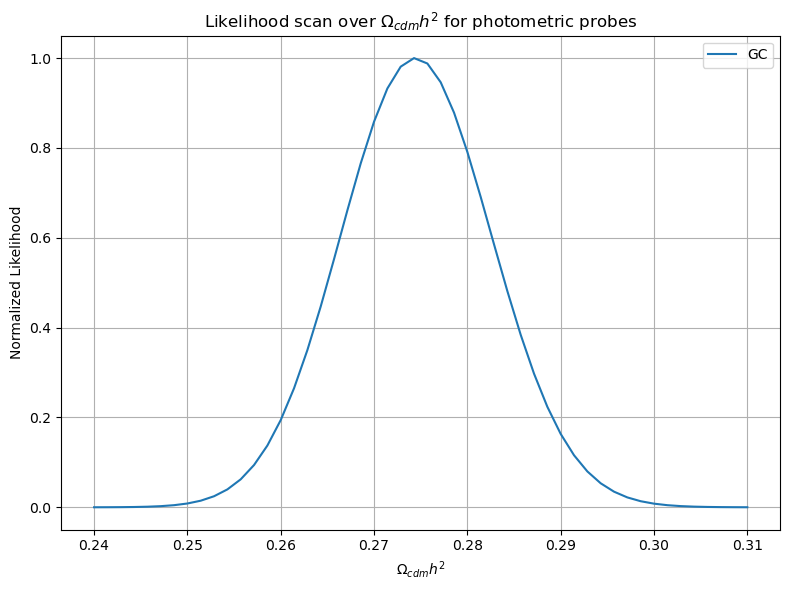

In [10]:
## Exploration of the parameter space
from tqdm import tqdm

# Define the range of Omega_cdm0 values to scan
oms = np.linspace(0.24, 0.31, 50)

# Prepare the figure
plt.figure(figsize=(8,6))

for label in ['GC']:
    print(f"\n🔄 Scanning over $\Omega_{{cdm}} h^2$ for {label}")
    likelihood_curve = []

    for om in tqdm(oms, desc=f"{label}", ncols=80):
        # Update Omega_cdm0 parameter from omch2 and H0
        default_pars['Omega_cdm0'] = om 

        # Compute log-likelihood
        ll = like_tests[label].loglike(default_pars)
        likelihood_curve.append(ll)
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
    likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
    plt.plot(oms, likelihood_curve, label=label)

plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\Omega_{cdm} h^2$ for photometric probes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Likelihood calculation for 2PCF

In [11]:
from cloelike.EuclidLikelihood_photo_2pcf import EuclidLikelihood_WL, EuclidLikelihood_GCph, EuclidLikelihood_3x2pt

In [12]:
from euclidlib.photo import correlation_functions
path_GC = 'EUC-WL-SA-example.fits'
path_WL = 'EUC-WL-CS-example.fits'
path_GGL = 'EUC-WL-GGL-example.fits'
#synthetic dv generated by cloelib with planck cosmology

raw_data_GC = correlation_functions(path_GC)
raw_data_WL = correlation_functions(path_WL)
raw_data_GGL = correlation_functions(path_GGL)
raw_data_3x2pt = {**raw_data_WL,**raw_data_GGL,**raw_data_GC}

covmat_GC = np.load('covariance_GC_2D.npz')['Gauss']
covmat_WL = np.load('covariance_WL_2D.npz')['Gauss']
covmat_3x2pt = np.load('covariance_3x2pt_2D.npz')['Gauss']

In [13]:
def build_data(cf_data,theta_key, cov, include_pos=False,include_she=False):
    data = {
        '2pcf': cf_data,
        'theta': cf_data[theta_key].ell,
        'z_arr': myz,
        'cov': cov,
        
    }
    if include_pos:
        data['dndz_pos'] = my_dndz_pos_norm
    if include_she:
        data['dndz_she'] = my_dndz_she_norm
    return data

def build_settings(cf_data):
    
    scale_cuts = {}
    for key in cf_data:
        if key[0] == 'SHE' and key[1] == 'SHE':
            scale_cuts[key] = [10, 250, 60, 250] #for xi_plus and xi_minus respectively
        else:
            scale_cuts[key] = [10, 250]
    
    return {'scale_cuts': scale_cuts}
# Build each dataset with correct dndz components
data_WL     = build_data(raw_data_WL,('SHE', 'SHE', 1, 1),covmat_WL,include_she=True)
data_GC     = build_data(raw_data_GC,('POS', 'POS', 1, 1),covmat_GC,include_pos=True)
data_3x2pt  = build_data(raw_data_3x2pt,('SHE', 'SHE', 1, 1),covmat_3x2pt,include_pos=True,include_she=True)

# Settings (same for all, built from cells_data structure)
settings_WL     = build_settings(raw_data_WL)
settings_GC     = build_settings(raw_data_GC)
settings_3x2pt  = build_settings(raw_data_3x2pt)


In [14]:
import time

likelihood_classes = {
    'WL': EuclidLikelihood_WL,
    'GC': EuclidLikelihood_GCph,
    '3x2pt': EuclidLikelihood_3x2pt,
}

data_dicts = {
    'WL': (data_WL, settings_WL),
    'GC': (data_GC, settings_GC),
    '3x2pt': (data_3x2pt, settings_3x2pt),
}

like_tests = {}
loglike_results = {}

print("🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:")

for label in ['WL', 'GC', '3x2pt']:
    print(f"\n📊 {label} loglike:")
    data, settings = data_dicts[label]
    cls = likelihood_classes[label]

    start = time.time()
    like_tests[label] = cls(
        data=data,
        settings=settings,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        ells_integration=np.arange(2, 60000)
    )
    end = time.time()

    print(f"⏱️ Time elapsed ({label}): {end - start:.3f} seconds")



🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:

📊 WL loglike:
⏱️ Time elapsed (WL): 0.000 seconds

📊 GC loglike:
⏱️ Time elapsed (GC): 0.000 seconds

📊 3x2pt loglike:
⏱️ Time elapsed (3x2pt): 0.000 seconds


In [15]:
# These are the default parameters used to generate the synthetic data, therefore, the log-likelihood should be close to zero.
default_pars = {'H0':67,'Omega_cdm0':0.27,'Omega_b0':0.049,'ns':0.96,'As':2.1e-9,
                'w0':-1,'wa':0, 'Omega_k0':0,'mnu':0.06,'gamma_MG':0.545, 'N_mnu': 1, 
                'log10TAGN': 7.8,
                'AIA':0.0, 'EtaIA': 0.0, 'CIA': 0.0,
                'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0,
                'b1_photo_poly2': 0, 'b1_photo_poly3': 0,
                'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                'dz_shear_5': 0.0, 'dz_shear_6': 0.0}

In [16]:
# Dictionary of pretty names for output
labels_pretty = {
    'WL': "Weak Lensing (WL)",
    'GC': "Photometric Angular Galaxy Clustering (GC)",
    '3x2pt': "3x2pt"
}

print("⏱️ Timing log-likelihood evaluations and displaying results:")

loglike_results = {}

for label in ['WL', 'GC', '3x2pt']:
    print(f"\n📊 {labels_pretty[label]} loglike:")
    start = time.time()
    result = like_tests[label].loglike(default_pars)
    elapsed = time.time() - start
    loglike_results[label] = result
    print(f"✅ Returned value ({label}): {result}")
    print(f"⏱️ Time elapsed ({label}): {elapsed:.3f} seconds")


⏱️ Timing log-likelihood evaluations and displaying results:

📊 Weak Lensing (WL) loglike:
✅ Returned value (WL): -0.022149068162084794
⏱️ Time elapsed (WL): 276.817 seconds

📊 Photometric Angular Galaxy Clustering (GC) loglike:
✅ Returned value (GC): -0.0035241442512873203
⏱️ Time elapsed (GC): 64.900 seconds

📊 3x2pt loglike:
✅ Returned value (3x2pt): -0.06916762182226194
⏱️ Time elapsed (3x2pt): 144.792 seconds


You can always retrieve the theoretical prediction computed during the $\chi^2$ calculation and the derived parameters such as (in dictionary shape):

In [17]:
print(like_tests['WL'].theory_prediction)
print(like_tests['WL'].derived)

{('SHE', 'SHE', 1, 1): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 1, 2): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 1, 3): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 1, 4): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 1, 5): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 1, 6): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 2, 2): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 2, 3): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 2, 4): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 2, 5): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 2, 6): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 3, 3): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 3, 4): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 3, 5): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 3, 6): TwoPointCorrelationFunction(axis=(2,)), ('SHE', 'SHE', 4, 4): TwoPointCorrelationFunction(axis=(2,)), ('SHE',

## Exploring the Parameter Space

This section illustrates how we explore the dependence of photometric observables on the cold dark matter density parameter, $\Omega_{\rm cdm} h^2$. We scan a range of values and evaluate the likelihood for each photometric probe: Weak Lensing (WL), Galaxy Clustering (GC), 2x2pt (GC + GGL), and 3x2pt.

The likelihoods are computed using the corresponding Euclid likelihood classes, and we normalize each resulting curve to its maximum value for easier visual comparison. A vertical dashed line indicates a fiducial $\Omega_{\rm cdm} h^2$ value (e.g., the best fit).

We use `tqdm` to visually track the progress of likelihood evaluations for each probe.


🔄 Scanning over $\Omega_{cdm} h^2$ for GC


GC: 100%|███████████████████████████████████████| 50/50 [00:32<00:00,  1.55it/s]


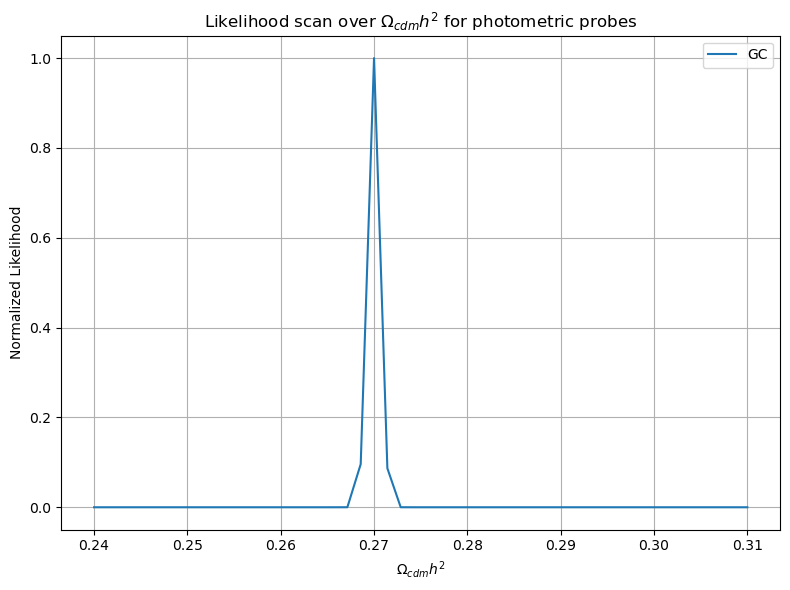

In [18]:
## Exploration of the parameter space
from tqdm import tqdm

# Define the range of Omega_cdm0 values to scan
oms = np.linspace(0.24, 0.31, 50)

# Prepare the figure
plt.figure(figsize=(8,6))

for label in ['GC']:
    print(f"\n🔄 Scanning over $\Omega_{{cdm}} h^2$ for {label}")
    likelihood_curve = []

    for om in tqdm(oms, desc=f"{label}", ncols=80):
        # Update Omega_cdm0 parameter from omch2 and H0
        default_pars['Omega_cdm0'] = om 

        # Compute log-likelihood
        ll = like_tests[label].loglike(default_pars)
        likelihood_curve.append(ll)
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
    likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
    plt.plot(oms, likelihood_curve, label=label)

plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\Omega_{cdm} h^2$ for photometric probes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
